# Compile experiment results into a dictionary

In [1]:
from tabpfn_project.paths import EXPERIMENTS_DATA_DIR, RESULTS_DIR, DATA_DIR, DISTNET_DATA_DIR
from tabpfn_project.globals import RANDOM_STATE

import platform
import pathlib
import pickle


metadata_dir = EXPERIMENTS_DATA_DIR / "experiment_context_sizes" / "metadata"
tabpfn_preds_dir = EXPERIMENTS_DATA_DIR / "experiment_context_sizes" / "tabpfn_preds_full"
results_dir = RESULTS_DIR / "experiment_context_sizes"
results_dir.mkdir(parents=True, exist_ok=True)

load_path = results_dir / "experiment_results_dict.pkl"
# with open(load_path, 'rb') as f:
#     experiment_results_dict = pickle.load(f)
# print("Loaded successfully.")
# print("Models:", list(experiment_results_dict.keys()))

In [2]:
# run if you want to re-create the experiment_results_dict.pkl file from the individual .pkl files in the metadata directory
from tabpfn_project.helper.utils import WindowsPathUnpickler


def fetch_save_dict(metadata_dir: pathlib.Path, model_name: str, scenario: str):
    experiment_results_dict = {}

    for fpath in metadata_dir.glob('*.pkl'):
        
        with open(fpath, 'rb') as f:
            # Use our custom Unpickler on Windows, otherwise standard pickle
            if platform.system() == 'Windows':
                results_dict = WindowsPathUnpickler(f).load()
            else:
                results_dict = pickle.load(f)

        context_size = results_dict['context_size']
        
        if results_dict['scenario'] != scenario:
            continue  # Skip if scenario doesn't match
        if context_size == 2**13 + 2000 or context_size == 2**13 + 4000:
            continue  # Skip these context sizes 
        
        model_name   = results_dict['model_name']
        scenario     = results_dict['scenario']
        fold         = results_dict['fold']
        seed_context = results_dict['seed_context']

        # Construct the nested dictionary
        experiment_results_dict \
            .setdefault(model_name, {}) \
            .setdefault(scenario, {}) \
            .setdefault(context_size, {}) \
            .setdefault(fold, {})[seed_context] = results_dict
    
    save_file_path = results_dir / f"{model_name}_{scenario}.pkl"
    
    with open(save_file_path, 'wb') as f:
        pickle.dump(experiment_results_dict, f)
        
    print(f"Saved to {save_file_path}")


In [3]:
# from tabpfn_project.globals import DISTNET_SCENARIOS


# ngboost_metadata_dir = EXPERIMENTS_DATA_DIR / "experiment_context_sizes" / "ngboost_default" / "metadata"
# qrf_metadata_dir = EXPERIMENTS_DATA_DIR / "experiment_context_sizes" / "qrf_default" / "metadata"


# for scenario in DISTNET_SCENARIOS:
#     fetch_save_dict(qrf_metadata_dir, "qrf_default", scenario)

# for scenario in DISTNET_SCENARIOS:
#     fetch_save_dict(ngboost_metadata_dir, "ngboost_default", scenario)

# Helpers

In [4]:
def load_tabpfn_preds(scenario_name, fold_idx, context_size, context_seed, seed_features, seed_samples_per_instance, feature_drop_rate, target_scale, subsample_method, num_samples_per_instance, use_cpu):
    fname = (
        f"tabpfn_{scenario_name}_{fold_idx}_{context_seed}_{seed_features}_{seed_samples_per_instance}_{feature_drop_rate}_"
                         f"{context_size}_{target_scale}_{subsample_method}_{num_samples_per_instance}_{'cpu' if use_cpu else 'gpu'}_test_preds.pkl"
    )
    fpath = tabpfn_preds_dir / fname
    with open(fpath, 'rb') as f:
        if platform.system() == 'Windows':
            preds = WindowsPathUnpickler(f).load()
        else:
            preds = pickle.load(f)
            
    return preds
    

# Calculate metrics of interest and store results

In [5]:
import torch
from tabpfn_project.globals import DISTNET_SCENARIOS, MODELS, DISTNET_CONTEXT_SIZES, DISTNET_CONTEXT_SEEDS, N_FOLDS, N_GRID_POINTS
from tabpfn_project.helper.load_data import load_distnet_data
import numpy as np
from tabpfn_project.helper import data_source_release, load_data
from sklearn.model_selection import KFold
from tabpfn_project.helper.distnet_helpers import (
    calculate_all_distribution_metrics_distnet_logspace,
)
from tabpfn_project.helper.pfn_helpers import calculate_distribution_metrics_logspace_tabpfn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def calculate_all_metrics(tabpfn_context_size_results, distnet_context_size_results):
    total_experiments = len(DISTNET_SCENARIOS) * len(MODELS) * len(DISTNET_CONTEXT_SIZES) * len(range(N_FOLDS)) * len(DISTNET_CONTEXT_SEEDS)
    current_experiment = 0
    for scenario in DISTNET_SCENARIOS:
        for model_name in MODELS:
            for context_size in DISTNET_CONTEXT_SIZES:
                for fold in range(N_FOLDS):
                    *_, y_test = load_distnet_data(DISTNET_DATA_DIR, scenario, fold)
                    for context_seed in DISTNET_CONTEXT_SEEDS:
                        case_dict = experiment_results_dict[model_name][scenario][context_size][fold][context_seed]

                        if model_name == 'tabpfn':
                            tabpfn_preds = load_tabpfn_preds(scenario, fold, context_size, context_seed, case_dict['seed_features'],
                                                            case_dict['seed_samples_per_instance'], case_dict['feature_drop_rate'],
                                                            case_dict['target_scale'], case_dict['subsample_method'],
                                                            case_dict['num_samples_per_instance'], case_dict['use_cpu'])
                            metrics_summary, instance_summary = calculate_distribution_metrics_logspace_tabpfn(y_test, tabpfn_preds, device=device, target_scale=case_dict['target_scale'], N_grid_points=N_GRID_POINTS)
                            tabpfn_context_size_results.append({
                                "scenario": scenario, "model": model_name, "context_size": context_size,
                                "fold": fold, "context_seed": context_seed,
                                "metrics_summ0ary": metrics_summary, "instance_summary": instance_summary
                            })

                        elif model_name == 'distnet':
                            metrics_summary, instance_summary = calculate_all_distribution_metrics_distnet_logspace(y_test, case_dict['test_preds'], device=device, y_scaler=case_dict['y_scale'], N_grid_points=N_GRID_POINTS)
                            distnet_context_size_results.append({
                                "scenario": scenario, "model": model_name, "context_size": context_size,
                                "fold": fold, "context_seed": context_seed,
                                "metrics_summary": metrics_summary, "instance_summary": instance_summary
                            })
                        
                        current_experiment += 1
                        print(f"✅Completed experiment {current_experiment}/{total_experiments}")


'''
tabpfn_context_size_results = []
distnet_context_size_results = []
calculate_all_metrics(tabpfn_context_size_results, distnet_context_size_results)
tabpfn_save_path = results_dir / "tabpfn_context_size_results.pkl"
with open(tabpfn_save_path, 'wb') as f:
    pickle.dump(tabpfn_context_size_results, f)
print(f"Saved TabPFN results ({len(tabpfn_context_size_results)} entries) to {tabpfn_save_path}")

distnet_save_path = results_dir / "distnet_context_size_results.pkl"
with open(distnet_save_path, 'wb') as f:
    pickle.dump(distnet_context_size_results, f)
print(f"Saved DistNet results ({len(distnet_context_size_results)} entries) to {distnet_save_path}")
'''

'\ntabpfn_context_size_results = []\ndistnet_context_size_results = []\ncalculate_all_metrics(tabpfn_context_size_results, distnet_context_size_results)\ntabpfn_save_path = results_dir / "tabpfn_context_size_results.pkl"\nwith open(tabpfn_save_path, \'wb\') as f:\n    pickle.dump(tabpfn_context_size_results, f)\nprint(f"Saved TabPFN results ({len(tabpfn_context_size_results)} entries) to {tabpfn_save_path}")\n\ndistnet_save_path = results_dir / "distnet_context_size_results.pkl"\nwith open(distnet_save_path, \'wb\') as f:\n    pickle.dump(distnet_context_size_results, f)\nprint(f"Saved DistNet results ({len(distnet_context_size_results)} entries) to {distnet_save_path}")\n'

In [ ]:
import torch
from tabpfn_project.globals import DISTNET_SCENARIOS, DISTNET_CONTEXT_SIZES, DISTNET_CONTEXT_SEEDS, N_FOLDS, N_GRID_POINTS
from tabpfn_project.helper.load_data import load_distnet_data
from tabpfn_project.helper.distnet_helpers import (
    calculate_all_distribution_metrics_distnet_logspace,
)
from tabpfn_project.helper.tree_based_models import calculate_all_distribution_metrics_ngboost_logspace, calculate_all_distribution_metrics_qrf_logspace_kde
from tabpfn_project.helper.utils import load_pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def calculate_all_metrics(ngboost_results, qrf_results, models):
    total_experiments = len(DISTNET_SCENARIOS) * len(models) * len(DISTNET_CONTEXT_SIZES) * len(range(N_FOLDS)) * len(DISTNET_CONTEXT_SEEDS)
    current_experiment = 0
    for scenario in DISTNET_SCENARIOS:
        for model_name in models:
            load_path = RESULTS_DIR / "experiment_context_sizes" / f"{model_name}_{scenario}.pkl"
            experiment_results_dict = load_pickle(load_path)
            for context_size in DISTNET_CONTEXT_SIZES:
                for fold in range(N_FOLDS):
                    *_, y_test = load_distnet_data(DISTNET_DATA_DIR, scenario, fold)
                    for context_seed in DISTNET_CONTEXT_SEEDS:
                        case_dict = experiment_results_dict[model_name][scenario][context_size][fold][context_seed]

                        if model_name == 'ngboost':
                            metrics_summary, instance_summary = calculate_all_distribution_metrics_ngboost_logspace(y_test, case_dict['test_preds'], device=device, y_scaler=case_dict['y_scale'], N_grid_points=N_GRID_POINTS)
                            ngboost_results.append({
                                "scenario": scenario, "model": model_name, "context_size": context_size,
                                "fold": fold, "context_seed": context_seed,
                                "metrics_summ0ary": metrics_summary, "instance_summary": instance_summary
                            })

                        elif model_name == 'qrf':
                            metrics_summary, instance_summary = calculate_all_distribution_metrics_qrf_logspace_kde(y_test, case_dict['test_preds'], device=device, y_scaler=None, N_grid_points=N_GRID_POINTS)
                            qrf_results.append({
                                "scenario": scenario, "model": model_name, "context_size": context_size,
                                "fold": fold, "context_seed": context_seed,
                                "metrics_summary": metrics_summary, "instance_summary": instance_summary
                            })
                        
                        current_experiment += 1
                        print(f"✅Completed experiment {current_experiment}/{total_experiments}")


models = ['ngboost', 'qrf']

ngboost_results = []
qrf_results = []
calculate_all_metrics(ngboost_results, qrf_results, models)
ngboost_save_path = results_dir / "ngboost_context_size_results.pkl"
with open(ngboost_save_path, 'wb') as f:
    pickle.dump(ngboost_results, f)
print(f"Saved NgBoost results ({len(ngboost_results)} entries) to {ngboost_save_path}")

qrf_save_path = results_dir / "qrf_context_size_results.pkl"
with open(qrf_save_path, 'wb') as f:
    pickle.dump(qrf_results, f)
print(f"Saved QRF results ({len(qrf_results)} entries) to {qrf_save_path}")

Train data loaded
Test data loaded
(2000, 113) (2000, 100)
Discarding 0 (2000) instances because of CRASHED
Discarding 0 (2000) instances because of TIMEOUT
Discarding 0 (2000) instances because not stated TIMEOUTS
Discarding 0 (2000) instances because of constant features
Discarding 0 (2000) instances because of UNSAT
Imputed 149 values with median
✅Completed experiment 1/9100
✅Completed experiment 2/9100
✅Completed experiment 3/9100
✅Completed experiment 4/9100
✅Completed experiment 5/9100
Train data loaded
Test data loaded
(2000, 113) (2000, 100)
Discarding 0 (2000) instances because of CRASHED
Discarding 0 (2000) instances because of TIMEOUT
Discarding 0 (2000) instances because not stated TIMEOUTS
Discarding 0 (2000) instances because of constant features
Discarding 0 (2000) instances because of UNSAT
Imputed 149 values with median
✅Completed experiment 6/9100
✅Completed experiment 7/9100
✅Completed experiment 8/9100
✅Completed experiment 9/9100
✅Completed experiment 10/9100
Train

### Visualization

Scenarios: ['clasp_factoring', 'saps-CVVAR', 'spear_qcp', 'yalsat_qcp', 'spear_swgcp', 'yalsat_swgcp', 'lpg-zeno']
Context sizes: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
Models: ['tabpfn', 'distnet']
Total aggregated entries: 728


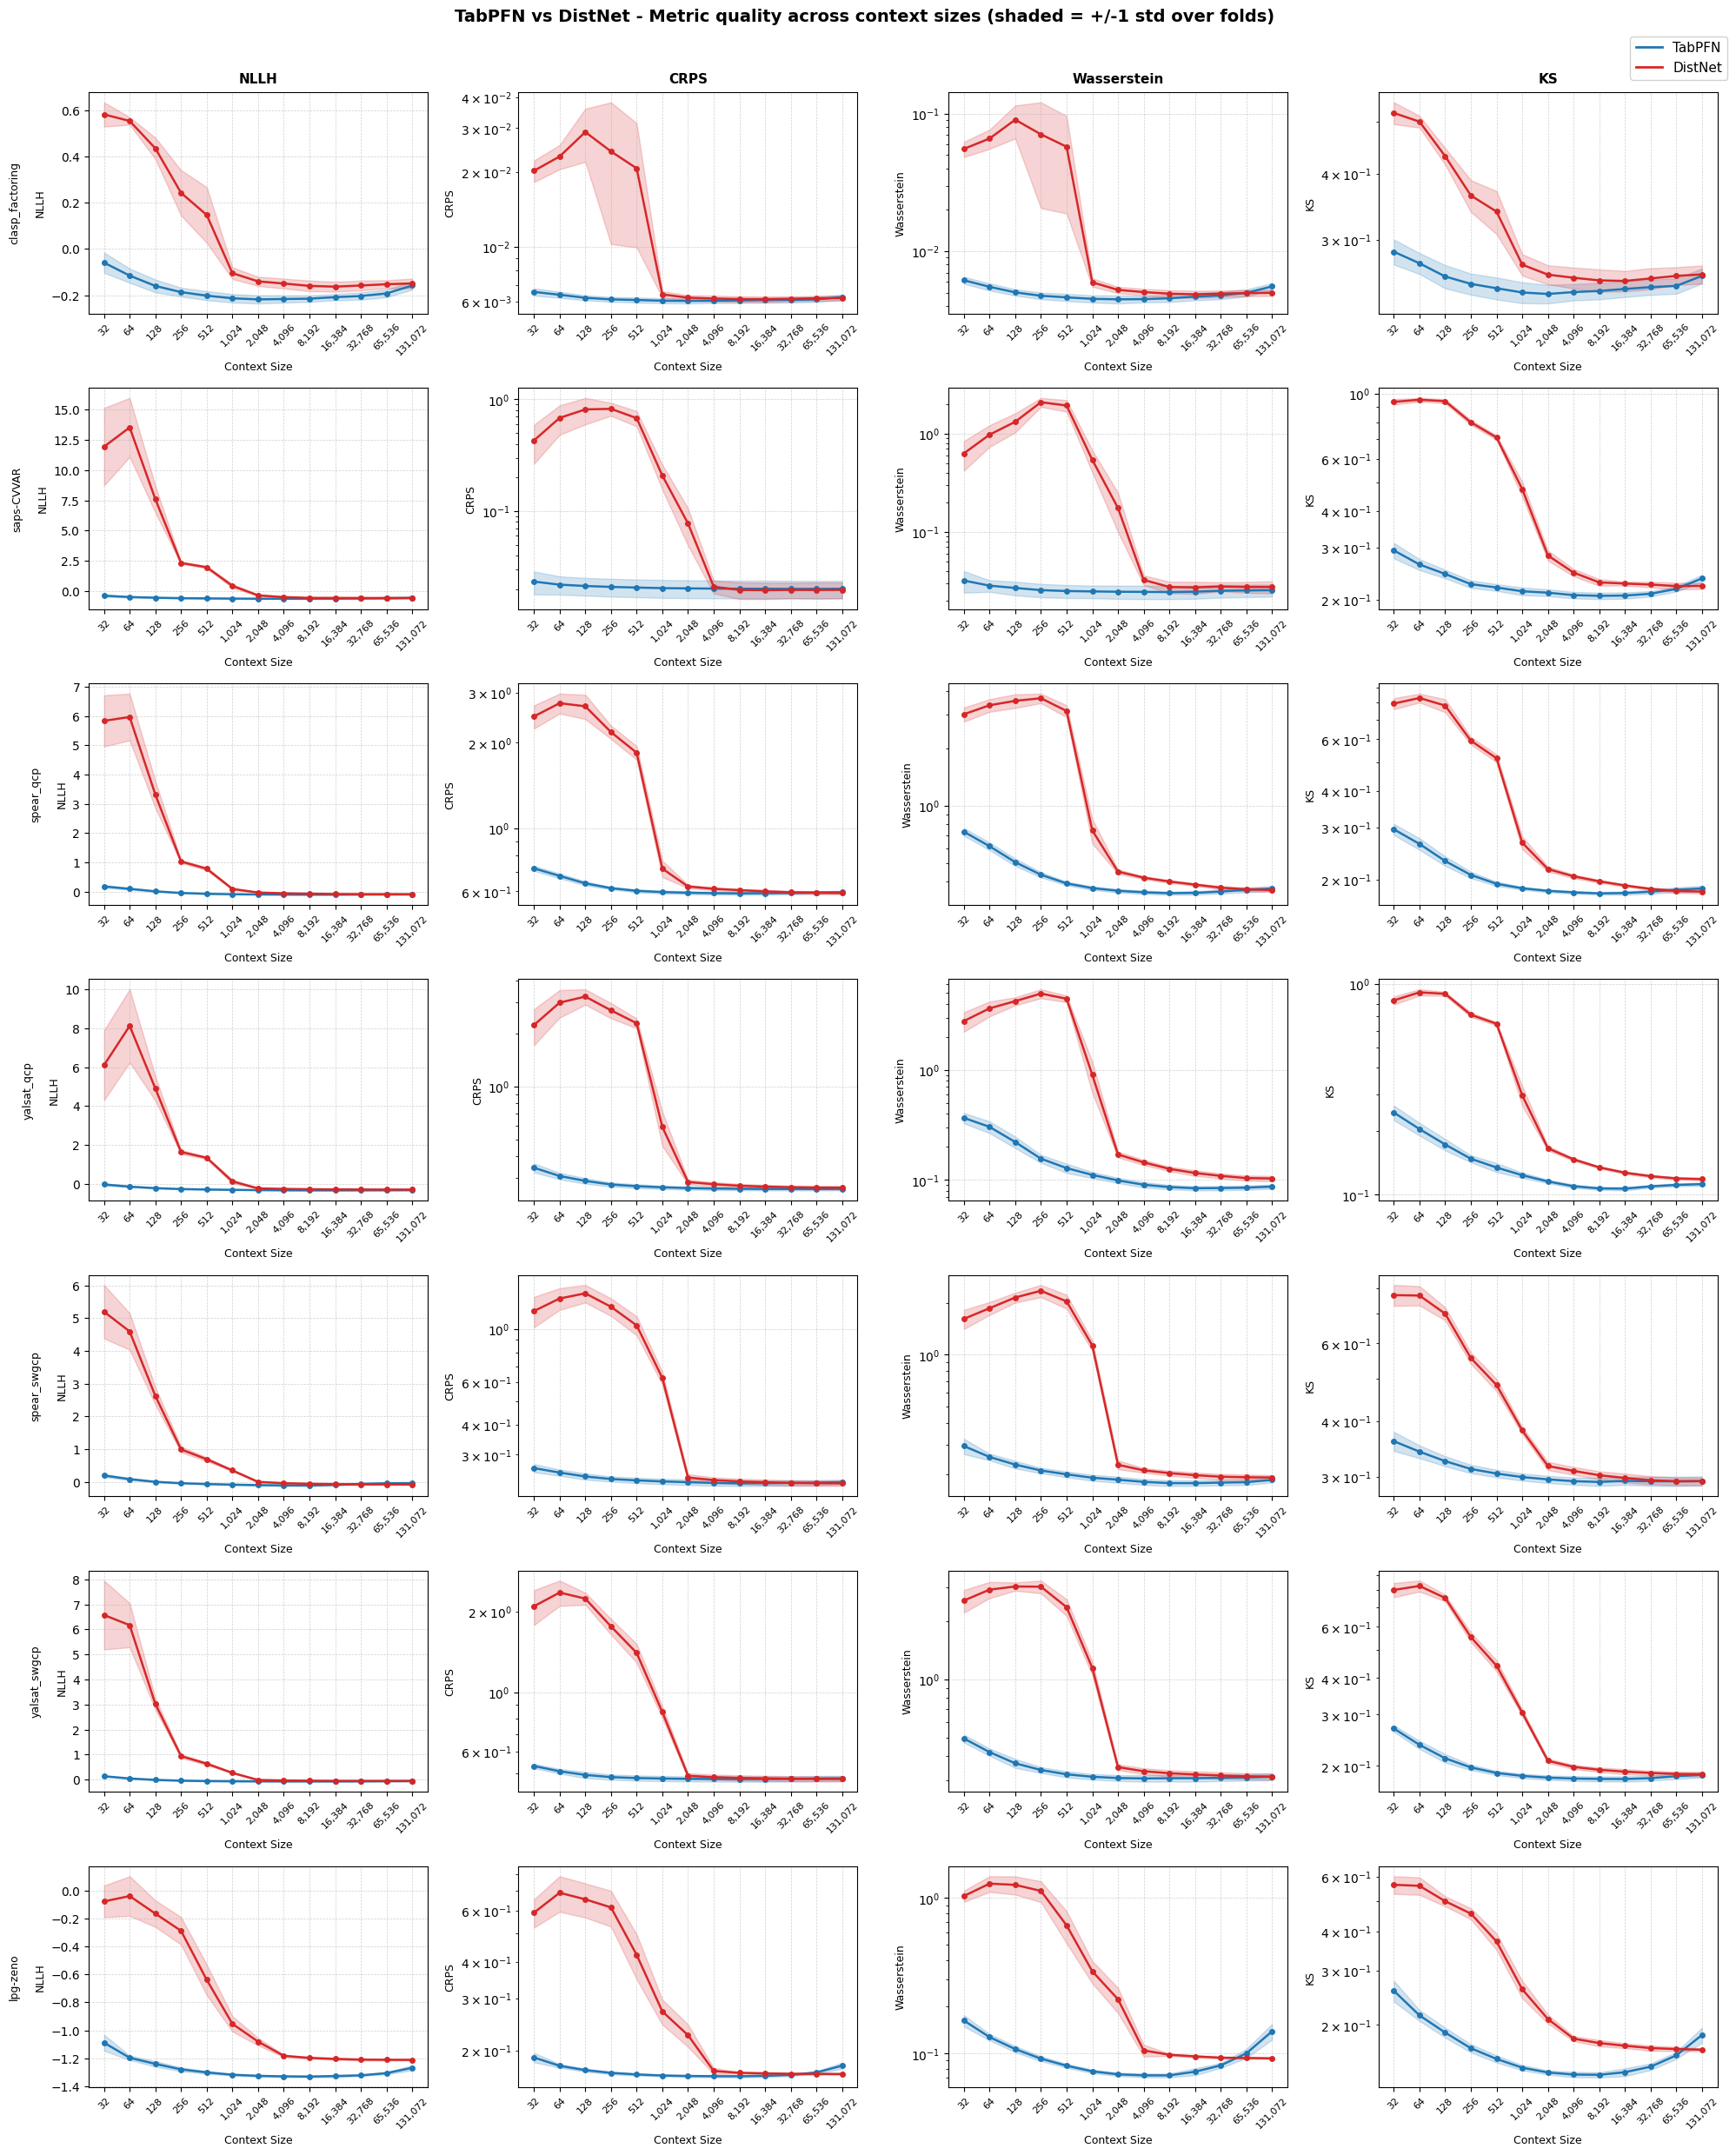

In [ ]:
from collections import defaultdict
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tabpfn_project.paths import RESULTS_DIR
from tabpfn_project.globals import DISTNET_SCENARIOS

results_dir = RESULTS_DIR / "experiment_context_sizes"

with open(f"{results_dir}/tabpfn_context_size_results.pkl", "rb") as f:
    tabpfn_results = pickle.load(f)

with open(f"{results_dir}/distnet_context_size_results.pkl", "rb") as f:
    distnet_results = pickle.load(f)

all_results = tabpfn_results + distnet_results

METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]

# ------------------------------------------------------------------
# Aggregation strategy requested:
# 1) For each (model, scenario, context_size, fold), average over seeds
# 2) For each (model, scenario, context_size), average over folds
# 3) Shade with std across folds
# ------------------------------------------------------------------

# (model, scenario, context_size, fold, metric) -> list of seed-level run scores
seed_scores_by_fold = defaultdict(list)

for entry in all_results:
    model = entry["model"]
    scenario = entry["scenario"]
    context_size = entry["context_size"]
    fold = entry["fold"]
    inst_summ = entry["instance_summary"]

    for metric in METRICS:
        vals = inst_summ[metric]
        if hasattr(vals, "cpu"):
            vals = vals.cpu().numpy()
        vals = np.asarray(vals).ravel()

        # One score per seed-run: mean over instances
        run_score = float(vals.mean())
        seed_scores_by_fold[(model, scenario, context_size, fold, metric)].append(run_score)

# (model, scenario, context_size, metric) -> list of fold means
fold_means = defaultdict(list)

for key, seed_scores in seed_scores_by_fold.items():
    model, scenario, context_size, fold, metric = key
    fold_mean = float(np.mean(seed_scores))
    fold_means[(model, scenario, context_size, metric)].append(fold_mean)

# Final plot data: mean/std over folds
plot_data = {}
for key, fold_scores in fold_means.items():
    scores = np.asarray(fold_scores, dtype=float)
    mean_over_folds = float(np.mean(scores))
    std_over_folds = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0
    plot_data[key] = (mean_over_folds, std_over_folds, len(scores))

# Keep all known scenarios visible (7 rows expected)
scenarios = list(DISTNET_SCENARIOS)
context_sizes = sorted({k[2] for k in plot_data.keys()})
models = ["tabpfn", "distnet"]

print(f"Scenarios: {scenarios}")
print(f"Context sizes: {context_sizes}")
print(f"Models: {models}")
print(f"Total aggregated entries: {len(plot_data)}")

MODEL_COLORS = {"tabpfn": "#1f77b4", "distnet": "#d62728"}
MODEL_LABELS = {"tabpfn": "TabPFN", "distnet": "DistNet"}
METRIC_LABELS = {"NLLH": "NLLH", "CRPS": "CRPS", "Wasserstein": "Wasserstein", "KS": "KS"}

n_rows = len(scenarios)
n_cols = len(METRICS)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    squeeze=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        for model in models:
            xs, means, stds = [], [], []
            for cs in context_sizes:
                key = (model, scenario, cs, metric)
                if key in plot_data:
                    m, s, n_folds = plot_data[key]
                    xs.append(cs)
                    means.append(m)
                    stds.append(s)

            if not xs:
                continue

            xs = np.array(xs, dtype=float)
            means = np.array(means, dtype=float)
            stds = np.array(stds, dtype=float)

            color = MODEL_COLORS[model]
            ax.plot(
                xs,
                means,
                marker="o",
                markersize=4,
                linewidth=1.8,
                color=color,
                label=MODEL_LABELS[model],
            )
            ax.fill_between(xs, means - stds, means + stds, alpha=0.20, color=color)

        ax.set_xscale("log", base=2)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        ax.set_xticks(context_sizes)
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)

        if metric in ("CRPS", "Wasserstein", "KS"):
            ax.set_yscale("log")

        ax.set_xlabel("Context Size", fontsize=9)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)

        if row_idx == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold", pad=8)

        if col_idx == 0:
            ax.set_ylabel(
                f"{scenario}\n\n{METRIC_LABELS[metric]}",
                fontsize=9,
            )

        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)

# Shared legend
handles = [
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2, label=MODEL_LABELS[m])
    for m in models
]
fig.legend(
    handles=handles,
    loc="upper right",
    fontsize=11,
    framealpha=0.9,
    bbox_to_anchor=(1.0, 1.0),
)

plt.suptitle(
    "TabPFN vs DistNet - Metric quality across context sizes (shaded = +/-1 std over folds)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

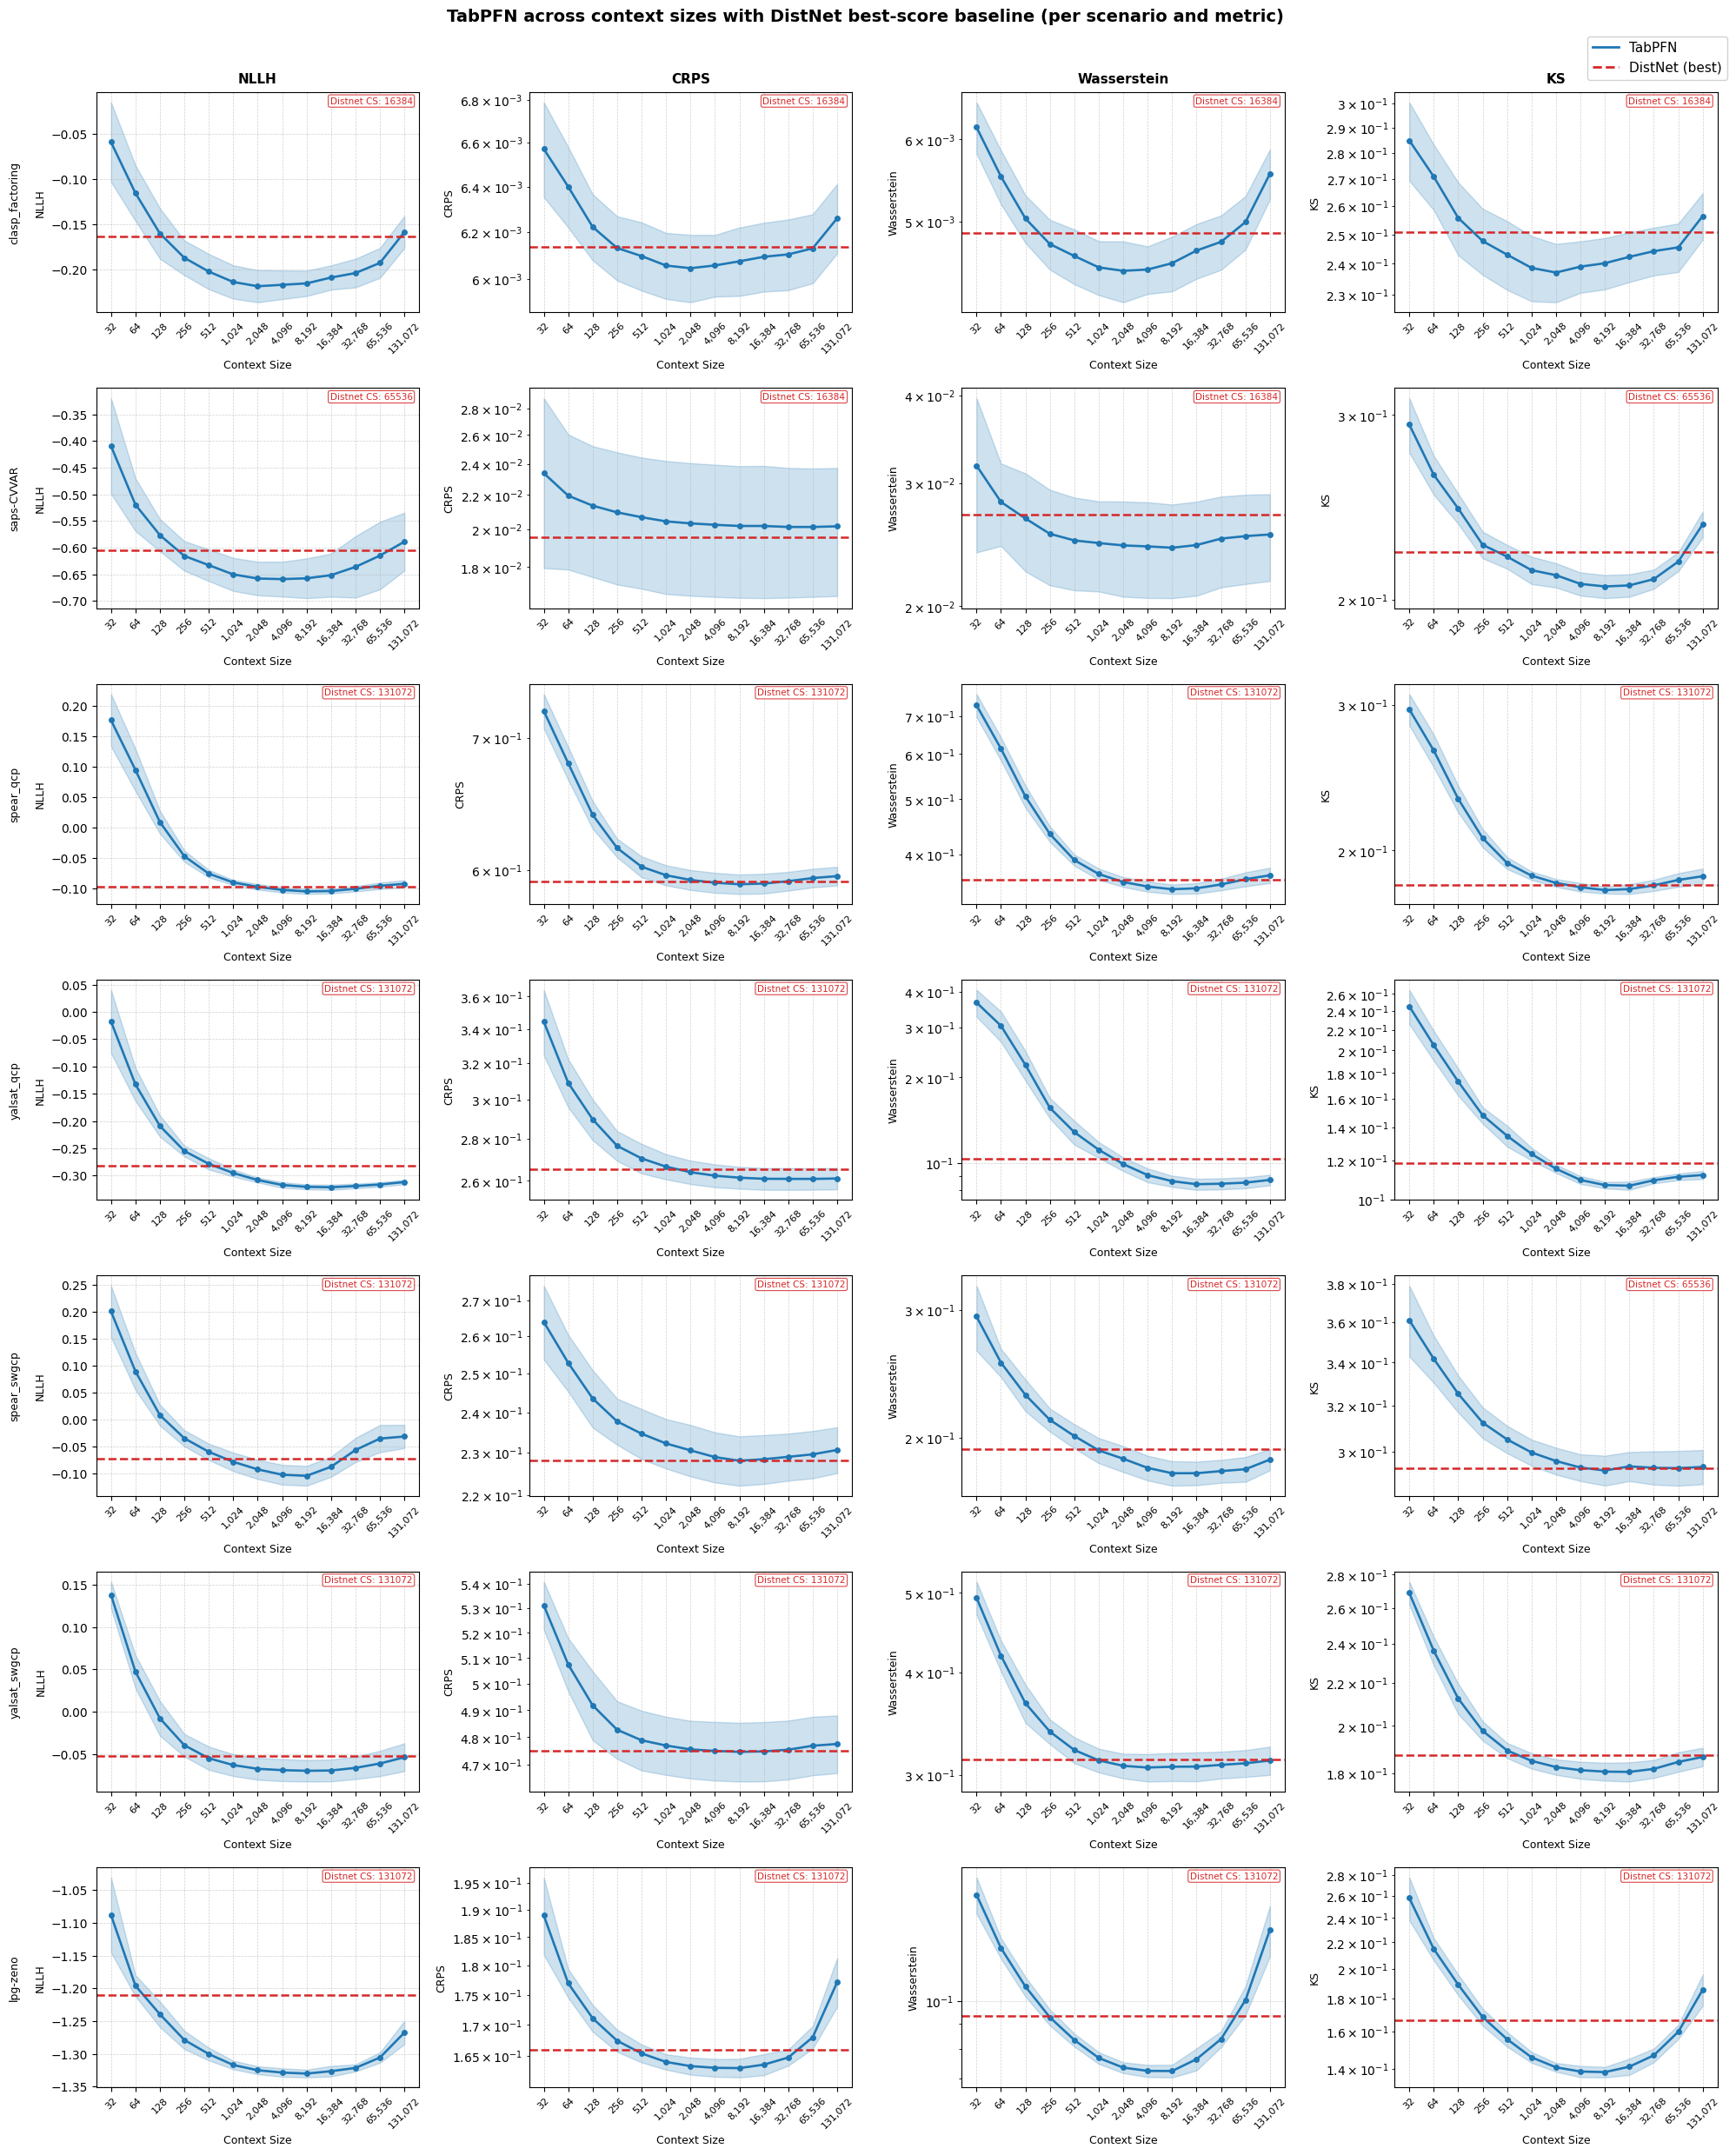

In [ ]:
from collections import defaultdict
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tabpfn_project.paths import RESULTS_DIR
from tabpfn_project.globals import DISTNET_SCENARIOS

results_dir = RESULTS_DIR / "experiment_context_sizes"

with open(f"{results_dir}/tabpfn_context_size_results.pkl", "rb") as f:
    tabpfn_results = pickle.load(f)

with open(f"{results_dir}/distnet_context_size_results.pkl", "rb") as f:
    distnet_results = pickle.load(f)

all_results = tabpfn_results + distnet_results
METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]

# ------------------------------------------------------------------
# Aggregate exactly as requested:
# 1) Average across seeds within each fold
# 2) Average across folds for each context size
# 3) Std across folds for TabPFN shading
# ------------------------------------------------------------------

seed_scores_by_fold = defaultdict(list)
# (model, scenario, context_size, fold, metric) -> list of run scores across seeds

for entry in all_results:
    model = entry["model"]
    scenario = entry["scenario"]
    context_size = entry["context_size"]
    fold = entry["fold"]
    inst_summ = entry["instance_summary"]

    for metric in METRICS:
        vals = inst_summ[metric]
        if hasattr(vals, "cpu"):
            vals = vals.cpu().numpy()
        vals = np.asarray(vals).ravel()

        run_score = float(vals.mean())  # mean over instances for this run
        seed_scores_by_fold[(model, scenario, context_size, fold, metric)].append(run_score)

fold_means = defaultdict(list)
# (model, scenario, context_size, metric) -> list of fold means

for key, seed_scores in seed_scores_by_fold.items():
    model, scenario, context_size, fold, metric = key
    fold_mean = float(np.mean(seed_scores))  # mean over seeds within fold
    fold_means[(model, scenario, context_size, metric)].append(fold_mean)

plot_data = {}
# (model, scenario, context_size, metric) -> (mean_over_folds, std_over_folds, n_folds)

for key, fold_scores in fold_means.items():
    scores = np.asarray(fold_scores, dtype=float)
    mean_over_folds = float(np.mean(scores))
    std_over_folds = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0
    plot_data[key] = (mean_over_folds, std_over_folds, len(scores))

scenarios = list(DISTNET_SCENARIOS)
context_sizes = sorted({k[2] for k in plot_data.keys()})

MODEL_COLORS = {"tabpfn": "#1f77b4", "distnet": "#d62728"}
METRIC_LABELS = {"NLLH": "NLLH", "CRPS": "CRPS", "Wasserstein": "Wasserstein", "KS": "KS"}

# Best DistNet score per (scenario, metric): lower is better for all metrics used here
# Store both value and context size.
distnet_best = {}
for scenario in scenarios:
    for metric in METRICS:
        distnet_points = []  # (mean_score, context_size)
        for cs in context_sizes:
            key = ("distnet", scenario, cs, metric)
            if key in plot_data:
                distnet_points.append((plot_data[key][0], cs))

        if distnet_points:
            # Tie-breaker: choose the smaller context size when best scores are equal
            best_val, best_cs = min(distnet_points, key=lambda p: (p[0], p[1]))
            distnet_best[(scenario, metric)] = (float(best_val), int(best_cs))

n_rows = len(scenarios)
n_cols = len(METRICS)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    squeeze=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        # TabPFN curve (mean across folds) + std band (std across folds)
        xs, means, stds = [], [], []
        for cs in context_sizes:
            key = ("tabpfn", scenario, cs, metric)
            if key in plot_data:
                m, s, _ = plot_data[key]
                xs.append(cs)
                means.append(m)
                stds.append(s)

        if xs:
            xs = np.asarray(xs, dtype=float)
            means = np.asarray(means, dtype=float)
            stds = np.asarray(stds, dtype=float)

            ax.plot(
                xs,
                means,
                marker="o",
                markersize=4,
                linewidth=1.9,
                color=MODEL_COLORS["tabpfn"],
                label="TabPFN",
            )
            ax.fill_between(
                xs,
                means - stds,
                means + stds,
                color=MODEL_COLORS["tabpfn"],
                alpha=0.22,
            )

        # DistNet baseline: constant line at best score over context sizes
        if (scenario, metric) in distnet_best:
            best_val, best_cs = distnet_best[(scenario, metric)]
            ax.axhline(
                y=best_val,
                color=MODEL_COLORS["distnet"],
                linestyle="--",
                linewidth=1.8,
                label="DistNet (best)",
            )

            # Small top-right box showing which context size yielded DistNet best
            ax.text(
                0.98,
                0.98,
                f"Distnet CS: {int(best_cs)}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=7.5,
                color=MODEL_COLORS["distnet"],
                bbox={
                    "boxstyle": "round,pad=0.20",
                    "facecolor": "white",
                    "edgecolor": MODEL_COLORS["distnet"],
                    "alpha": 0.85,
                    "linewidth": 0.8,
                },
            )

        ax.set_xscale("log", base=2)
        ax.set_xticks(context_sizes)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)

        if metric in ("CRPS", "Wasserstein", "KS"):
            ax.set_yscale("log")

        if row_idx == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold", pad=8)

        ax.set_xlabel("Context Size", fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f"{scenario}\n\n{METRIC_LABELS[metric]}", fontsize=9)
        else:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)

        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)

handles = [
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS["tabpfn"], linewidth=2, label="TabPFN"),
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS["distnet"], linestyle="--", linewidth=2, label="DistNet (best)"),
]
fig.legend(handles=handles, loc="upper right", fontsize=11, framealpha=0.9, bbox_to_anchor=(1.0, 1.0))

plt.suptitle(
    "TabPFN across context sizes with DistNet best-score baseline (per scenario and metric)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()